# Experiment 2: Explicit Reflection Location via Maximum Reflection Filter (MaxRF)

In this notebook, we visualize the theoretical backbone of the Reflection Detection Network (RDNet). Local reflections often cause texture details in the contaminated image that are completely absent in the transmission layer. By exploiting this, we can explicitly represent reflection locations using the **Maximum Reflection Filter (MaxRF)**.

### Mathematical Formulation

1. First, we compute the gradient maps for both the reflection-contaminated image ($I$) and the transmission image ($T$) using the Sobel operator ($Grad(\cdot)$).
2. Because global ambient light reduces the original transmission gradients, any remaining strong gradients in $I$ are overwhelmingly indicative of local reflection contents.
3. We define the explicit reflection map $M_{local}$ by performing a maximum comparison in the gradient domain:

$$M_{local}^{(i,j)} = \begin{cases} 1 & \text{if } G_{I}^{(i,j)} > G_{T}^{(i,j)} \\ 0 & \text{otherwise} \end{cases}$$

Where $G_I$ and $G_T$ are the gradient magnitudes of $I$ and $T$ respectively.

In [1]:
import os, sys
import glob

sys.path.append(os.path.abspath(".."))
from analysis_modules.physics_viz import analyze_reflection_physics

# Define paths
base_path = '/storage/hdd1/data/amanr.mds2024/robustsirr_test_dataset/'
output_path = './results/all_datasets_eval/'

dataset_name = 'OpenRR100'
rel_path = 'OpenRR100'

dir_I = os.path.join(base_path, rel_path, 'blended')
dir_T = os.path.join(base_path, rel_path, 'transmission_layer')
dir_M_local_hat = os.path.join(output_path, dataset_name, 'Real-location_gray')

# Select a target file dynamically
target_files = sorted(glob.glob(os.path.join(dir_M_local_hat, '*.png')))
target_file = target_files[2] if len(target_files) > 2 else target_files[0]
base_name = os.path.splitext(os.path.basename(target_file))[0]

# Resolve paths
path_I = glob.glob(os.path.join(dir_I, f"{base_name}.*"))[0]
path_T = glob.glob(os.path.join(dir_T, f"{base_name}.*"))[0]
path_M_local_hat = target_file

print(f"Target Image: {os.path.basename(path_I)}")

Target Image: test_0003.jpg


### Visualizing Physical Gradients vs. Model Estimations

Grayscale gradient maps are difficult to parse visually. To make the network's behavior intuitive, we display the original colored images alongside **Heatmaps** of the detection masks using a decluttered 2-row layout.

It is vital to understand the difference between these two definitions:
1.  **$M_{local}$ (Loc G_T):** This is a deterministic **binary indicator map**. We generate it strictly comparing the physical gradients: if $G_I > G_T$, the value is 1, else 0. The JET heatmap therefore only shows strict deep blue (zero) or strict bright red (reflection).
2.  **$\hat{M}_{local}$ (Model Confidence):** This is the network's **continuous probability/confidence map**. Values range smoothly from [0, 1]. The JET heatmap shows color gradients (blue $\rightarrow$ green $\rightarrow$ yellow $\rightarrow$ red) mapping low-to-high confidence.

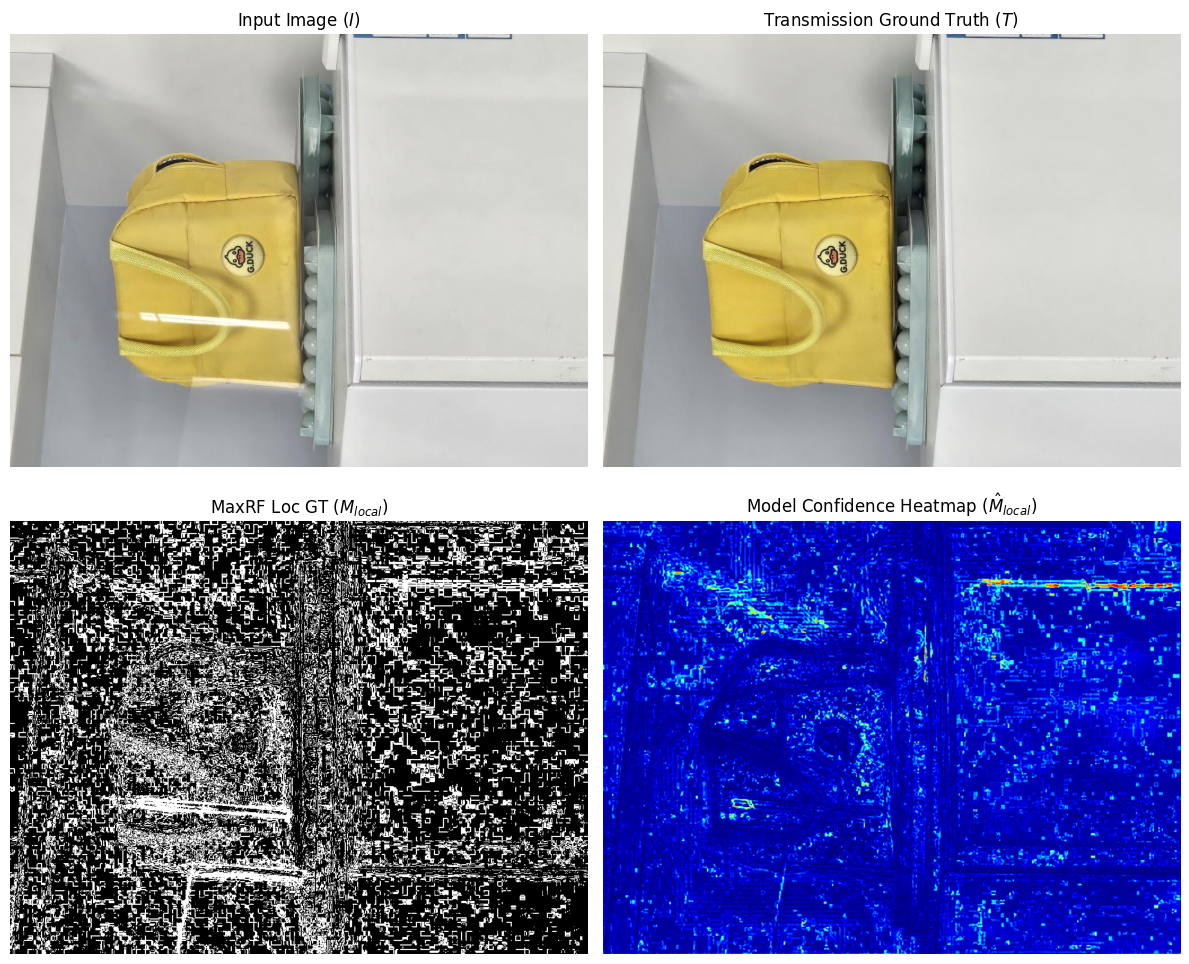

In [2]:
# Analyze and plot
analyze_reflection_physics(path_I, path_T, path_M_local_hat)